<script src="/course_model/toc.js"></script>

# Principle Component Analysis (PCA)

PCA is a method for reducing the number of columns while retaining as much information as possible.

**Outcomes**:
- Explain the basics of the PCA algorithm
- Define variance, principal components, and orthogonal
- Explain why we want to reduce the number of columns in a dataset
- Explain why we may add the PCs back onto an original dataset
- Explain how graphing the PCs can help us understand the data
- Apply PCA for dimensionality reduction

**Links**
- [template census data](census.csv) and [PCA example](census_pca_example.ipynb)

## PCA Algorithm

Principal Component Analysis (PCA) is a technique for:

* *Reducing dimensionality* (many features → fewer features),
* While *preserving as much variance as possible*,
* By creating new, *uncorrelated* features called *principal components*.

Each principal component is:

* A linear combination of the original features.
* Orthogonal (perpendicular) to the others.
* Ordered so that:

  * PC1 explains the most variance,
  * PC2 explains the second most variance,
  * etc.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Create a dataset of predefined car samples
df = pd.DataFrame({
    'engine_displacement': [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 1.8, 2.2, 2.8, 3.5, 4.2, 5.5],
    'num_cylinders': [3, 4, 4, 4, 5, 6, 6, 8, 8, 8, 10, 10, 12, 12, 4, 4, 6, 6, 8, 8],
    'engine_power': [120, 160, 200, 250, 280, 320, 380, 450, 520, 580, 600, 640, 650, 720, 140, 180, 300, 350, 520, 600],
    'price': [25000, 32000, 38000, 45000, 52000, 60000, 72000, 85000, 95000, 110000, 125000, 135000, 145000, 150000, 28000, 35000, 55000, 65000, 90000, 120000],
    'weight': [2500, 2700, 2900, 3100, 3300, 3600, 3900, 4200, 4500, 4700, 4900, 5000, 5100, 5200, 2600, 2800, 3200, 3500, 4300, 4600],
    'mpg': [38, 32, 28, 25, 22, 20, 18, 16, 14, 12, 11, 10, 9, 8, 35, 30, 21, 19, 15, 12],
    'year': [2023, 2023, 2023, 2022, 2022, 2022, 2021, 2021, 2020, 2020, 2019, 2019, 2018, 2018, 2023, 2023, 2022, 2022, 2021, 2020],
    'acceleration': [10.5, 8.2, 7.1, 6.5, 6.0, 5.5, 5.0, 4.5, 4.2, 3.9, 3.7, 3.5, 3.3, 3.0, 9.8, 8.0, 6.8, 6.2, 4.8, 4.0]
})

# Add car type classification
df['car_type'] = df.apply(
    lambda row: 'Sports Car' if (row['engine_power'] >= 400 or row['acceleration'] < 5.0) else 'Economy Car',
    axis=1
)

# PCA works best when features are centered; standardization is often used when units differ.
X = df[['engine_displacement', 'num_cylinders', 'engine_power', 'price', 'weight', 'mpg', 'year', 'acceleration']].values  # shape: (20, 8)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 
# `X_scaled` has mean ~0 and variance ~1 in each column.

# Fit PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Principal components (directions):")
print(pca.components_)

Principal components (directions):
[[ 0.35663352  0.35106612  0.35776287  0.35699674  0.35874068 -0.35013588
  -0.35279264 -0.34405162]
 [ 0.13807797  0.35411536  0.01102768  0.24256939 -0.01602305  0.49075458
  -0.38000873  0.64114884]]


In [10]:
# Show how the principal component scores map back into the original variables
print("\nPrincipal component scores (projections):")
print(X_pca)

# Display loadings - how each variable aligns with each component
feature_names = ['engine_displacement', 'num_cylinders', 'engine_power', 'price', 'weight', 'mpg', 'year', 'acceleration']
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_names
)

print("\n\nLoadings - Alignment of Variables with Principal Components:")
print("(Shows how strongly each variable contributes to each PC)")
print(loadings_df)

print("\n\nVariable Contributions (sorted by absolute value):")
print("\nPC1 - Top contributors:")
print(loadings_df['PC1'].abs().sort_values(ascending=False))
print("\nPC2 - Top contributors:")
print(loadings_df['PC2'].abs().sort_values(ascending=False))


Principal component scores (projections):
[[-4.47305525  1.01239304]
 [-3.41510905  0.18644614]
 [-2.77413926 -0.30144973]
 [-2.01184745 -0.34278791]
 [-1.38674124 -0.45324969]
 [-0.7335913  -0.50296825]
 [ 0.07604103 -0.42887747]
 [ 0.96266473 -0.31329746]
 [ 1.74070809 -0.18980161]
 [ 2.28919508 -0.26651954]
 [ 3.18508469  0.23903071]
 [ 3.55484559  0.2190217 ]
 [ 4.34716719  0.6955037 ]
 [ 4.74551173  0.61650451]
 [-3.94681628  0.80369696]
 [-3.16107063  0.04555603]
 [-1.45018632 -0.16103636]
 [-0.83915274 -0.34751079]
 [ 1.02302003 -0.30238363]
 [ 2.26747136 -0.20827034]]


Loadings - Alignment of Variables with Principal Components:
(Shows how strongly each variable contributes to each PC)
                          PC1       PC2
engine_displacement  0.356634  0.138078
num_cylinders        0.351066  0.354115
engine_power         0.357763  0.011028
price                0.356997  0.242569
weight               0.358741 -0.016023
mpg                 -0.350136  0.490755
year           

#### Add PCA results back to a DataFrame

We can now use the PCA results to do further analysis or visualization.


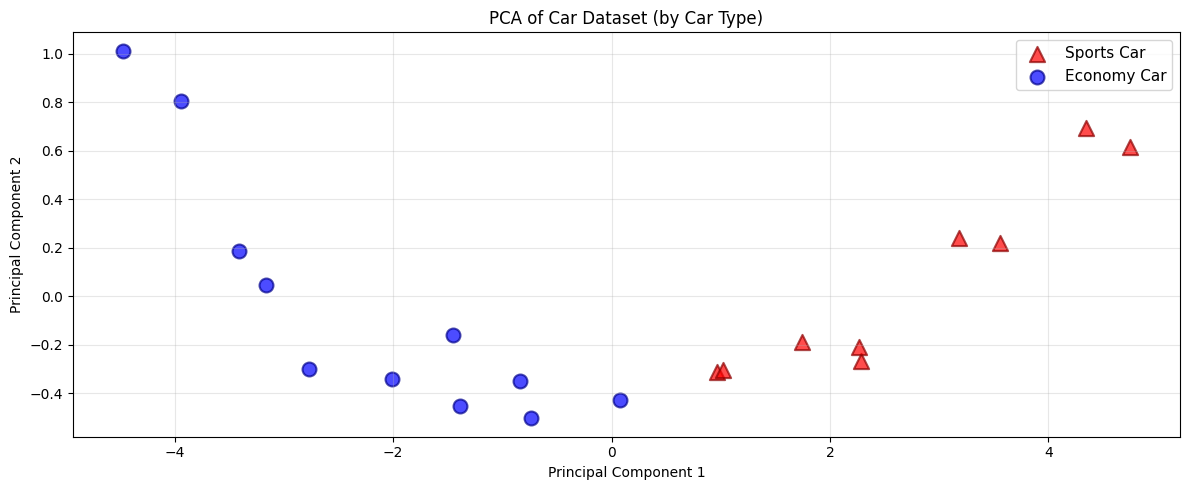

In [12]:
df_pca = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

df_with_pca = pd.concat([df.reset_index(drop=True), df_pca], axis=1)

import matplotlib.pyplot as plt

# Plot PCA-transformed data colored and shaped by car type
plt.figure(figsize=(12, 5))

# Separate data by car type
sports_cars = df_with_pca[df_with_pca['car_type'] == 'Sports Car']
economy_cars = df_with_pca[df_with_pca['car_type'] == 'Economy Car']

# Plot each group with different color and marker shape
plt.scatter(sports_cars['PC1'], sports_cars['PC2'], c='red', marker='^', s=120, alpha=0.7, label='Sports Car', edgecolors='darkred', linewidth=1.5)
plt.scatter(economy_cars['PC1'], economy_cars['PC2'], c='blue', marker='o', s=100, alpha=0.7, label='Economy Car', edgecolors='darkblue', linewidth=1.5)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Car Dataset (by Car Type)')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Example PCA Process

This image show the PCA training process on a dataset with three features reduced to two principal components.
![PCA Process](pca_training.gif)